# Standalone RR / HRV preprocessing branch

**Purpose.** Convert a verified single-lead ECG segment into independent
R-peak timestamp tracks, RR intervals, heart rate, reliability context,
and causal 100-RR Jeppesen measurements.

**This notebook contains:** explicit configuration; input validation;
NeuroKit and Zhai detector intermediates; detector association; RR
construction; 7-RR causal median filtering; Poincaré SD1/SD2; CSI;
modified CSI; heart-rate slope; J1/J2; reliability coverage; plots;
exports; assertions; limitations; and complete source snapshots.

**It does not:** choose a timestamp winner, remove intervals because two
detectors disagree, label artifact, or predict seizures.

### Data flow

```text
physical ECG
  ├─ NeuroKit gradient detector ─┬─ RR intervals ── 100-RR HRV
  │                              └─ reliability context versus Zhai
  └─ Zhai 2023 reimplementation ┬─ RR intervals ── 100-RR HRV
                                 └─ reliability context versus NeuroKit
```

## 1. Reproducible environment and data selection

This notebook is **independent of the other notebooks**. It locates the
project, imports the installed/tested branch package, selects one ECG
channel explicitly, creates its own output directory, and records the
runtime versions. The executable example uses MIT–BIH record 100,
channel `MLII`, starting at 0 s for 120 s.

Change only the configuration cell below to use another WFDB record.
For EDF data, use `ecg_cascade.edf.load_ecg_segment` after explicitly
inspecting and choosing the ECG channel.

#### Code walkthrough — imports, project discovery, and frozen run configuration

        **Why this cell exists.** Every later result depends on using the intended package, dataset, lead, units, and output folder.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Imports | Loads hashing, tables, numerical methods, plotting, NeuroKit, WFDB, and notebook display helpers. | The notebook needs both computation and visible audit evidence. |
| 2 | Project discovery | Searches the current directory and its parents for `pyproject.toml` and `src/ecg_cascade`, then places `src` on `sys.path`. | The same notebook must run from the repository root or its own folder without importing an unrelated installed copy. |
| 3 | Output contract | Creates one branch-specific directory under `outputs/standalone_notebooks`. | CSV, JSON, and manifests remain separate and reproducible. |
| 4 | Input configuration | Freezes record 100, lead MLII, start, duration, and patient identifier; the header assertion fails early if data are missing. | A clinical reader must know exactly which signal produced the figures. |
| 5 | Display configuration | Applies a consistent plot style and wide table display. | Successful runs should be readable without hidden columns or default styling ambiguity. |
| 6 | Version printout | Prints Python and dependency versions plus resolved paths. | A future rerun can distinguish data or code changes from environment changes. |

        **Evidence that the cell ran correctly**

        - A compact version block is printed with Python, NumPy, pandas, SciPy, NeuroKit2, and WFDB versions.
- `Project` resolves to the repository's `feature_extraction` folder and `Output` resolves to this branch's folder.
- No import, missing-file, or path assertion error appears.

        **If that evidence is absent, investigate**

        - A wrong working directory or a missing `feature_extraction/pyproject.toml`.
- The MIT–BIH dataset path or the requested lead name.
- A notebook kernel that is not using the project virtual environment.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import neurokit2 as nk
import wfdb
from IPython.display import Code, Markdown, display

# Locate feature_extraction regardless of whether execution starts from
# the repository root, feature_extraction, or the notebook directory.
search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT = next(
    path for path in search_roots
    if (path / "pyproject.toml").is_file()
    and (path / "src" / "ecg_cascade").is_dir()
)
ROOT = PROJECT.parent
SRC = PROJECT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

OUTPUT_DIR = PROJECT / "outputs" / "standalone_notebooks" / "rr_hrv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEMO_RECORD = (
    ROOT / "Datasets" / "mit-bih-arrhythmia-database-1.0"
    / "mit-bih-arrhythmia-database-1.0.0" / "100"
)
assert DEMO_RECORD.with_suffix(".hea").is_file(), DEMO_RECORD

RECORD_PATH = DEMO_RECORD       # WFDB path without extension
CHANNEL = "MLII"                # explicit lead choice
START_S = 0.0
DURATION_S = 120.0
PATIENT_ID = "mitdb_100"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelcolor": "#304955",
    "text.color": "#203845",
})
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Python:", platform.python_version())
print("NumPy:", np.__version__, "Pandas:", pd.__version__, "SciPy:", scipy.__version__)
print("NeuroKit2:", nk.__version__, "WFDB:", wfdb.__version__)
print("Project:", PROJECT)
print("Output:", OUTPUT_DIR)

Python: 3.12.10
NumPy: 2.4.2 Pandas: 2.3.3 SciPy: 1.17.0
NeuroKit2: 0.2.13 WFDB: 4.3.1
Project: C:\Users\Salam\Documents\ECGdetector\feature_extraction
Output: C:\Users\Salam\Documents\ECGdetector\feature_extraction\outputs\standalone_notebooks\rr_hrv


#### Code walkthrough — load, validate, summarize, and preview the input ECG

        **Why this cell exists.** Algorithm outputs are interpretable only after the waveform, sampling rate, time coordinates, units, and finite-sample checks are visible.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Loader import | Imports the project's WFDB segment loader. | This centralizes channel lookup and physical-unit conversion instead of duplicating raw WFDB calls. |
| 2 | Segment read | Loads the configured lead and time range, then extracts samples and sampling frequency. | Every sample index used later must map to a physical time. |
| 3 | Time axis | Builds an absolute time vector from the segment start and sample rate. | Plots and event tables then share the same coordinate system. |
| 4 | Assertions | Requires one-dimensional, finite data and at least three seconds of signal. | Downstream filters and interval calculations should fail visibly rather than accept malformed input. |
| 5 | Summary | Prints source, lead, sampling rate, sample count, time span, and amplitude range. | This is the run's input provenance and first unit sanity check. |
| 6 | Preview figure | Plots the first 12 seconds of the unmodified physical ECG. | A reviewer can see polarity, gain, baseline, and recognizable beats before any branch operates. |

        **Evidence that the cell ran correctly**

        - The summary reports 360 Hz, the requested duration, finite amplitude limits, and channel MLII.
- The figure shows a continuous ECG trace with no blank panel or clipped time axis.
- The x-axis is seconds and the y-axis explicitly says physical WFDB units.

        **If that evidence is absent, investigate**

        - Lead selection, start/duration bounds, or a corrupt/missing WFDB pair.
- NaN/Inf samples, an unexpectedly flat trace, or an amplitude scale inconsistent with the header.
- A wrong sampling rate, because every millisecond conversion below depends on it.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

{'source': 'C:\\Users\\Salam\\Documents\\ECGdetector\\Datasets\\mit-bih-arrhythmia-database-1.0\\mit-bih-arrhythmia-database-1.0.0\\100', 'channel': 'MLII', 'sampling_rate_hz': 360.0, 'samples': 43200, 'start_s': 0.0, 'duration_s': 120.0, 'minimum': -0.695, 'maximum': 1.125}


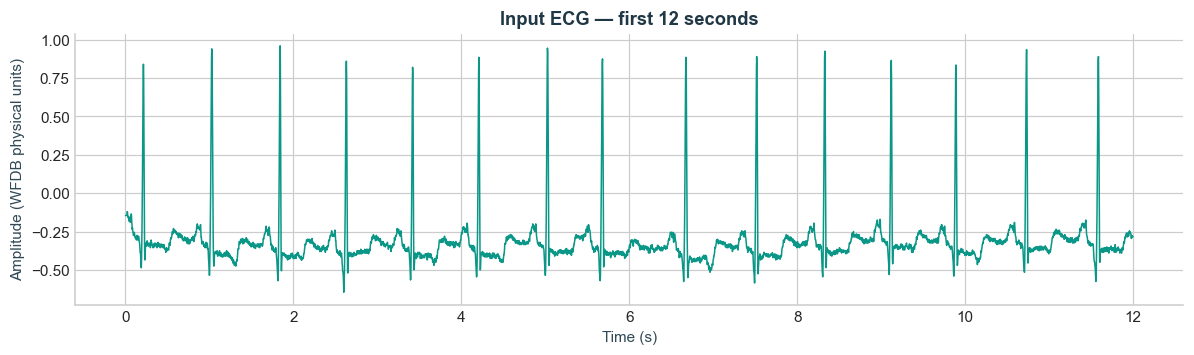

In [2]:
from ecg_cascade.wfdb_io import load_wfdb_segment

segment = load_wfdb_segment(
    RECORD_PATH,
    channel=CHANNEL,
    start_s=START_S,
    duration_s=DURATION_S,
)
ecg = segment.samples
fs = float(segment.sampling_rate_hz)
time_s = segment.start_s + np.arange(ecg.size) / fs

assert ecg.ndim == 1
assert np.all(np.isfinite(ecg))
assert ecg.size >= int(3 * fs)
print({
    "source": segment.record_path,
    "channel": segment.channel_name,
    "sampling_rate_hz": fs,
    "samples": int(ecg.size),
    "start_s": segment.start_s,
    "duration_s": segment.duration_s,
    "minimum": float(ecg.min()),
    "maximum": float(ecg.max()),
})

preview = time_s < time_s[0] + 12
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(time_s[preview], ecg[preview], color="#0b9787", lw=1.0)
ax.set(title="Input ECG — first 12 seconds", xlabel="Time (s)", ylabel="Amplitude (WFDB physical units)")
plt.show()

### Reproducibility rules used throughout

- No missing-sample imputation is performed.
- The selected channel and physical-unit scale are shown explicitly.
- Detector disagreement is context, not ground truth or artifact.
- All rolling windows are trailing/causal where the implementation says so.
- No notebook cell trains a seizure classifier or produces a clinical label.
- Tables are exported separately so intermediate measurements remain auditable.

## 2. Freeze the branch configuration

The two timestamp sequences are calculated independently. Matching at
±50 ms supplies context only; it does not splice, average, or vote on
timestamps. The HRV window contains exactly 100 consecutive RR intervals.

For RR values \(RR_i\) in milliseconds:

\[
HR_i = \frac{60000}{RR_i}, \qquad
SD1 = SD\left(\frac{RR_{i+1}-RR_i}{\sqrt{2}}\right), \qquad
SD2 = SD\left(\frac{RR_{i+1}+RR_i}{\sqrt{2}}\right)
\]

\[
CSI = \frac{SD2}{SD1}, \qquad
ModCSI = \frac{4SD2_f^2}{SD1_f}, \qquad
J1 = CSI\,|slope(HR_f)|, \qquad
J2 = ModCSI\,|slope(HR_f)|
\]

The subscript \(f\) refers to the causal seven-RR median-filtered series.

#### Code walkthrough — freeze detector association and 100-RR feature parameters

        **Why this cell exists.** A tolerance, delay, window width, or causal filter change can materially change detector support and HRV values, so none may remain implicit.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Configuration import | Imports the immutable NeuroKit–Zhai configuration and cascade entry point. | Both detector tracks use one recorded contract. |
| 2 | Orientation | Keeps the original lead orientation and disables the separate inverted-context experiment. | This run should not silently choose polarity from its own output. |
| 3 | Detector timing | Sets NeuroKit's strict 300-ms delay and two association tolerances. | Minimum separation affects double detections; matching affects context and audit only. |
| 4 | HRV construction | Requires exactly 100 RR intervals and a trailing seven-RR median. | These values implement the documented Jeppesen-style continuous feature construction. |
| 5 | Reliability policy | Requires complete RR support for the reliability flag. | A continuous value can remain defined while its support context is recorded separately. |
| 6 | Configuration display | Shows every stored parameter. | The PI can see the complete frozen contract before execution. |

        **Evidence that the cell ran correctly**

        - A two-column configuration table appears and includes 100 RR, median width 7, and 50-ms support tolerance.
- No timestamp-owner or classifier setting is introduced.

        **If that evidence is absent, investigate**

        - A changed default hidden outside the printed configuration.
- Confusing support tolerance with expert-audit tolerance.
- Treating `reliable_hrv_coverage=1.0` as a clinical validity threshold.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [3]:
from ecg_cascade import NeuroKitZhaiConfig, run_neurokit_zhai_array

config = NeuroKitZhaiConfig(
    processing_orientation="original",
    compute_inverted_context=False,
    neurokit_minimum_delay_ms=300.0,
    neurokit_minimum_delay_inclusive=False,
    support_tolerance_ms=50.0,
    audit_match_tolerance_ms=75.0,
    hrv_window_rr_intervals=100,
    causal_rr_median_width=7,
    reliable_hrv_coverage=1.0,
)
display(pd.Series(config.to_dict(), name="value").to_frame())

,value
processing_orientation,original
compute_inverted_context,False
neurokit_minimum_delay_ms,300.0
neurokit_minimum_delay_inclusive,False
support_tolerance_ms,50.0
audit_match_tolerance_ms,75.0
hrv_window_rr_intervals,100
causal_rr_median_width,7
reliable_hrv_coverage,1.0
varon_pre_r_ms,60.0


## 3. Run both timestamp tracks and inspect detector-level evidence

#### Code walkthrough — run the two independent detector-to-HRV tracks

        **Why this cell exists.** The central scientific question is what each timestamp owner produces before any fusion decision.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Cascade call | Processes the same ECG through NeuroKit and the Zhai reimplementation with the frozen configuration. | Direct comparison requires identical input and scope. |
| 2 | Track dictionary | Names the two independent results without selecting or averaging them. | Each RR series must preserve single-detector timestamp ownership. |
| 3 | Detector summary | Collects event, interval, support, defined-feature, and reliable-feature counts. | Counts reveal missing beats, extras, warm-up, and support loss. |
| 4 | Association display | Shows one-to-one agreement at the audit tolerance. | Agreement is evidence about correspondence, not proof of correct physiology. |

        **Evidence that the cell ran correctly**

        - Both rows contain positive event and RR counts.
- At least one 100-RR feature row is defined for each track.
- The association table is finite and does not replace either timestamp list.

        **If that evidence is absent, investigate**

        - Detector failure or an ECG segment too short to reach 100 RR intervals.
- Unexpected event-count differences after a dependency/configuration change.
- Any code that merges or moves timestamps during association.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [4]:
cascade = run_neurokit_zhai_array(
    ecg,
    fs,
    segment_start_s=segment.start_s,
    config=config,
    source_metadata={"record": str(RECORD_PATH), "channel": CHANNEL},
)
tracks = {
    "NeuroKit": cascade.selected.neurokit,
    "Zhai": cascade.selected.zhai,
}
detector_summary = pd.DataFrame({name: track.summary() for name, track in tracks.items()}).T
display(detector_summary[[
    "event_count", "rr_interval_count", "supported_event_count",
    "supported_rr_count", "defined_hrv_rows", "reliable_hrv_rows"
]])
display(pd.Series(cascade.selected.audit_agreement.to_dict(), name="detector association at 75 ms"))

,event_count,rr_interval_count,supported_event_count,supported_rr_count,defined_hrv_rows,reliable_hrv_rows
NeuroKit,148,147,148,147,48,48
Zhai,148,147,148,147,48,48


agreement_f1                     1.0
median_timing_difference_ms      0.0
unmatched_primary_fraction       0.0
unmatched_comparator_fraction    0.0
matched_count                    148
primary_count                    148
comparator_count                 148
unmatched_primary_samples         []
unmatched_comparator_samples      []
Name: detector association at 75 ms, dtype: object

#### Code walkthrough — overlay each detector's R anchors on the same ECG

        **Why this cell exists.** A numerical event count cannot reveal whether a marker sits on a QRS, T wave, or noise deflection.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Figure layout | Creates one shared-time panel per detector for the first 15 seconds. | Separate panels avoid marker occlusion while preserving visual comparability. |
| 2 | ECG trace | Plots the identical raw ECG in both panels. | Differences must come from timestamps, not different preprocessing displays. |
| 3 | Time conversion | Converts detector sample indices to absolute seconds. | WFDB annotations and later tables use the same coordinate. |
| 4 | Marker interpolation | Places colored points at each detected time using the raw signal amplitude. | Markers visibly land on waveform deflections. |
| 5 | Labels | Adds detector legends and shared units. | The screenshot can be explained without reading variable names. |

        **Evidence that the cell ran correctly**

        - Two aligned panels appear, each with markers close to visible QRS complexes.
- The x-axes span 0–15 s and the detector colors/legends are distinct.

        **If that evidence is absent, investigate**

        - A sample-to-time conversion error if markers are horizontally shifted.
- Incorrect channel polarity or a detector reacting repeatedly to non-QRS waves.
- A blank marker set caused by a failed detector.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

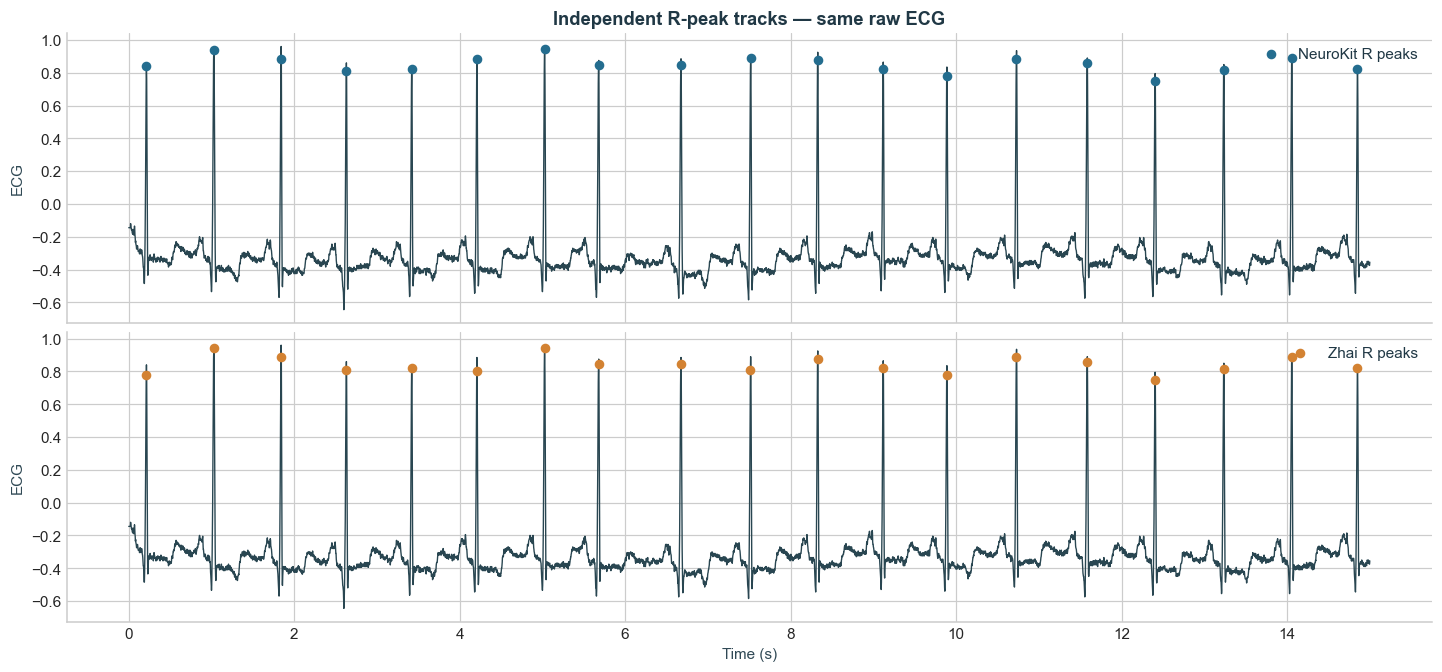

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, constrained_layout=True)
view_start, view_end = 0.0, 15.0
visible = (time_s >= view_start) & (time_s <= view_end)
colors = {"NeuroKit": "#246d8f", "Zhai": "#d38232"}
for ax, (name, track) in zip(axes, tracks.items()):
    ax.plot(time_s[visible], ecg[visible], color="#294651", lw=0.9)
    peak_times = segment.start_s + track.detector.peak_samples / fs
    shown = (peak_times >= view_start) & (peak_times <= view_end)
    y = np.interp(peak_times[shown], time_s, ecg)
    ax.scatter(peak_times[shown], y, s=28, color=colors[name], zorder=3, label=f"{name} R peaks")
    ax.legend(loc="upper right")
    ax.set_ylabel("ECG")
axes[0].set_title("Independent R-peak tracks — same raw ECG")
axes[-1].set_xlabel("Time (s)")
plt.show()

## 4. RR construction and reliability context

An RR interval joins consecutive timestamps **within the same detector
track**. Unsupported intervals are retained; `rr_supported` and
`reliability_reason` travel beside the measurement. This avoids turning
detector disagreement into false physiological missingness.

#### Code walkthrough — inspect event and RR tables and recompute every interval

        **Why this cell exists.** RR values must be direct differences of consecutive timestamps from one detector; otherwise all HRV features are scientifically invalid.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Track selection | Chooses the NeuroKit lane for a transparent hand audit while leaving Zhai intact. | One lane is enough to demonstrate the invariant. |
| 2 | Table display | Shows the first event rows and RR rows. | Identifiers, times, support, and reason fields are visible. |
| 3 | Independent recomputation | Calculates `diff(peak_samples) * 1000 / fs`. | This is the simplest reference equation for RR milliseconds. |
| 4 | Exact comparison | Uses NumPy testing to compare every recomputed value with the stored table. | A silent row shift or cross-track interval fails immediately. |

        **Evidence that the cell ran correctly**

        - The event and interval previews share coherent indices/times.
- The final printed sentence confirms every NeuroKit RR interval passed the direct difference check.

        **If that evidence is absent, investigate**

        - Off-by-one event/interval alignment.
- A milliseconds-versus-seconds unit error.
- Any accidental interval built across two different detector tracks.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [6]:
neurokit_track = cascade.selected.neurokit
display(neurokit_track.events.head(8))
display(neurokit_track.rr_intervals.head(8))

rr_check = np.diff(neurokit_track.detector.peak_samples) * 1000.0 / fs
np.testing.assert_allclose(rr_check, neurokit_track.rr_intervals["rr_ms"].to_numpy(float))
print("Direct timestamp-difference check passed for every NeuroKit RR interval.")

,event_index,primary_detector,comparator_detector,primary_timestamp_sample,primary_timestamp_time_s,comparator_match_count,nearest_comparator_sample,comparator_offset_ms,qrs_supported,timestamp_moved_after_detection,zhai_absolute_correlation
0,0,neurokit,zhai,77,0.213889,1,76,-2.777778,True,False,0.996979
1,1,neurokit,zhai,370,1.027778,1,370,0.000000,True,False,0.985502
2,2,neurokit,zhai,662,1.838889,1,662,0.000000,True,False,0.997684
3,3,neurokit,zhai,946,2.627778,1,946,0.000000,True,False,1.000000
4,4,neurokit,zhai,1231,3.419444,1,1231,0.000000,True,False,0.985315
5,5,neurokit,zhai,1515,4.208333,1,1514,-2.777778,True,False,0.994368
6,6,neurokit,zhai,1809,5.025000,1,1809,0.000000,True,False,0.994743
7,7,neurokit,zhai,2044,5.677778,1,2044,0.000000,True,False,0.994792


,rr_index,timestamp_owner_track,start_r_sample,end_r_sample,start_time_s,end_time_s,rr_samples,rr_ms,heart_rate_bpm,start_qrs_supported,end_qrs_supported,comparator_events_in_expanded_rr,rr_supported,reliability_reason
0,0,neurokit,77,370,0.213889,1.027778,293,813.888889,73.720137,True,True,2,True,supported
1,1,neurokit,370,662,1.027778,1.838889,292,811.111111,73.972603,True,True,2,True,supported
2,2,neurokit,662,946,1.838889,2.627778,284,788.888889,76.056338,True,True,2,True,supported
3,3,neurokit,946,1231,2.627778,3.419444,285,791.666667,75.789474,True,True,2,True,supported
4,4,neurokit,1231,1515,3.419444,4.208333,284,788.888889,76.056338,True,True,2,True,supported
5,5,neurokit,1515,1809,4.208333,5.025000,294,816.666667,73.469388,True,True,2,True,supported
6,6,neurokit,1809,2044,5.025000,5.677778,235,652.777778,91.914894,True,True,2,True,supported
7,7,neurokit,2044,2402,5.677778,6.672222,358,994.444444,60.335196,True,True,2,True,supported


Direct timestamp-difference check passed for every NeuroKit RR interval.


#### Code walkthrough — show RR, causal filtering, and mature J1/J2 outputs over time

        **Why this cell exists.** This figure connects detector timestamps to the time series that a non-coder will actually interpret.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Two-panel canvas | Allocates a tachogram panel and a mature-feature panel with shared time. | Raw timing and derived values can be compared vertically. |
| 2 | Raw RR | Plots each interval endpoint against its RR duration. | Extras, misses, and ectopy appear as abrupt interval changes. |
| 3 | Causal median-7 | Overlays the current-plus-previous-six RR median. | The reader can see what short spikes the documented filter suppresses. |
| 4 | Defined mask | Plots J1/J2 only after their 100-RR prerequisite is satisfied. | Warm-up is honest missingness, not zero. |
| 5 | Legends and units | Names both tracks and both products. | The screenshot is self-contained. |

        **Evidence that the cell ran correctly**

        - The upper panel contains dots plus smoother median curves for both tracks.
- The lower panel begins later because 100 RR intervals are required.
- No early J1/J2 values are fabricated.

        **If that evidence is absent, investigate**

        - A flat or explosive RR series indicating missed/extra peaks.
- A non-causal centered median if changes appear before their inputs.
- Feature values appearing before the 100th RR row.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

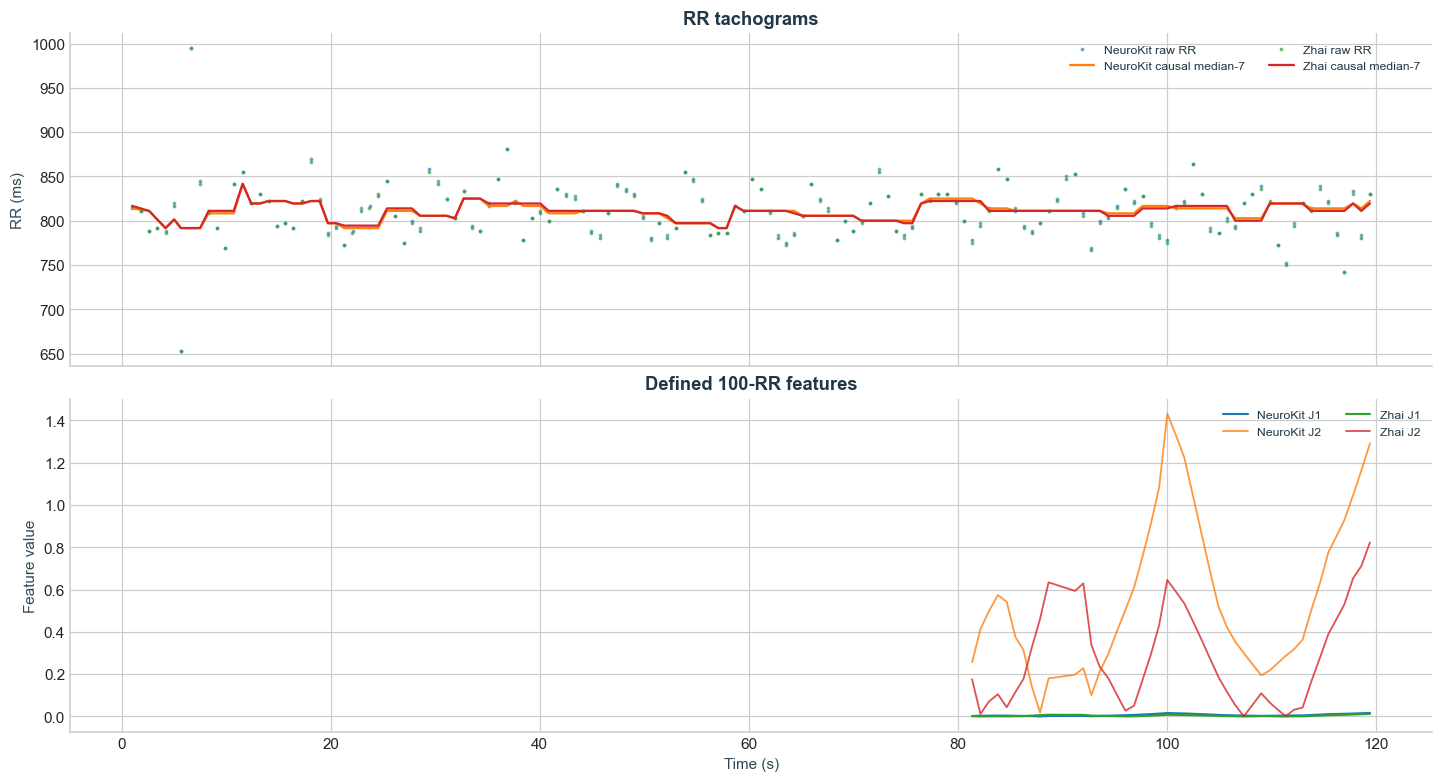

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, constrained_layout=True)
for name, track in tracks.items():
    frame = track.features
    axes[0].plot(frame["end_time_s"], frame["rr_ms"], ".", ms=3, alpha=0.55, label=f"{name} raw RR")
    axes[0].plot(frame["end_time_s"], frame["rr_median7_ms"], lw=1.5, label=f"{name} causal median-7")
    defined = frame["feature_defined"]
    axes[1].plot(frame.loc[defined, "end_time_s"], frame.loc[defined, "j1_csi_x_slope"], lw=1.4, label=f"{name} J1")
    axes[1].plot(frame.loc[defined, "end_time_s"], frame.loc[defined, "j2_modcsi_filtered_x_slope"], lw=1.2, alpha=.8, label=f"{name} J2")
axes[0].set(title="RR tachograms", ylabel="RR (ms)")
axes[1].set(title="Defined 100-RR features", xlabel="Time (s)", ylabel="Feature value")
for ax in axes: ax.legend(ncol=2, fontsize=8)
plt.show()

## 5. Hand-check the latest 100-RR Poincaré window

#### Code walkthrough — hand-check one 100-RR Poincaré window

        **Why this cell exists.** SD1 and SD2 are geometric quantities; recomputing and plotting one complete window makes the equations tangible and auditable.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Mature row selection | Finds the latest row where the 100-RR feature is defined. | It avoids a warm-up row with intentional NaNs. |
| 2 | Window slice | Extracts exactly the current and preceding 99 RR intervals. | The published feature family has a fixed 100-interval context. |
| 3 | Independent axes | Calls the small Poincaré reference function and compares SD1/SD2 with stored columns. | A window-boundary or axis-definition error becomes an assertion failure. |
| 4 | Scatter plot | Plots each RR against its successor plus the identity line. | Width across and length along the identity direction explain SD1/SD2 visually. |
| 5 | Feature row | Displays CSI, modified CSI, slope, J1/J2, and reliability beside the plot. | Geometry, derived products, and context are linked at one timestamp. |

        **Evidence that the cell ran correctly**

        - A 99-point Poincaré cloud appears with finite SD1 and SD2 in the title.
- The stored/direct comparison passes and the displayed row says `feature_defined=True`.

        **If that evidence is absent, investigate**

        - Fewer than 100 intervals, an empty defined-row set, or a slice boundary error.
- SD1/SD2 swapped or calculated from filtered data in the raw path.
- Interpreting the identity line as a clinical normal range.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

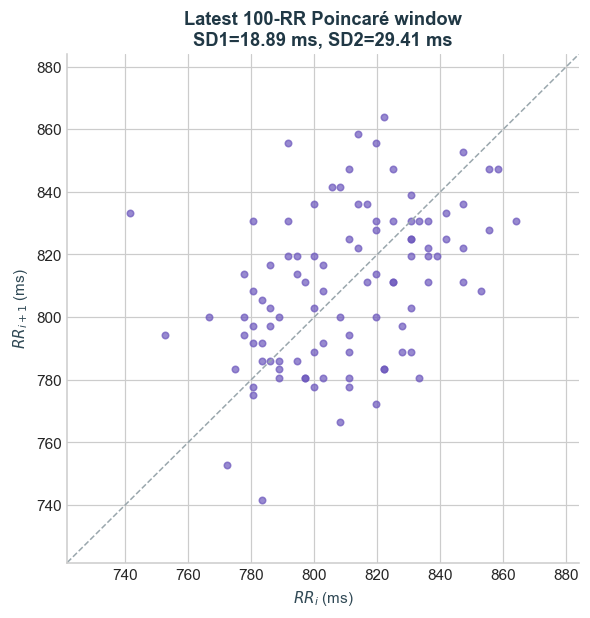

end_time_s                    119.433333
sd1_raw_ms                     18.893005
sd2_raw_ms                     29.409895
csi100                          1.556655
modcsi100_filtered_ms         121.728378
slope100_bpm_per_s              0.010613
j1_csi_x_slope                  0.016521
j2_modcsi_filtered_x_slope      1.291886
rr_reliability_coverage              1.0
feature_defined                     True
feature_reliable                    True
Name: 146, dtype: object

In [8]:
from ecg_cascade.rr_hrv import poincare_axes

hrv = neurokit_track.features
last_defined = int(np.flatnonzero(hrv["feature_defined"].to_numpy(bool))[-1])
first = last_defined - config.hrv_window_rr_intervals + 1
rr100 = hrv.loc[first:last_defined, "rr_ms"].to_numpy(float)
sd1_check, sd2_check = poincare_axes(rr100)
row = hrv.loc[last_defined]
np.testing.assert_allclose([sd1_check, sd2_check], [row.sd1_raw_ms, row.sd2_raw_ms])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(rr100[:-1], rr100[1:], s=18, color="#6d58bd", alpha=.7)
limits = [min(rr100) - 20, max(rr100) + 20]
ax.plot(limits, limits, "--", color="#9aa7ad", lw=1)
ax.set(xlim=limits, ylim=limits, xlabel=r"$RR_i$ (ms)", ylabel=r"$RR_{i+1}$ (ms)",
       title=f"Latest 100-RR Poincaré window\nSD1={sd1_check:.2f} ms, SD2={sd2_check:.2f} ms")
plt.show()
display(row[["end_time_s", "sd1_raw_ms", "sd2_raw_ms", "csi100", "modcsi100_filtered_ms",
             "slope100_bpm_per_s", "j1_csi_x_slope", "j2_modcsi_filtered_x_slope",
             "rr_reliability_coverage", "feature_defined", "feature_reliable"]])

## 6. Case study — record 113 shows why disagreement is not artifact

The repository's prior [record-113 case report](../../reports/MITBIH_Record_113_TWave_Double_Detection_Case_Analysis.pdf)
found a specific detector failure: NeuroKit matched almost every expert
QRS but also placed 1,039 full-record extra markers on broad waves about
306–356 ms after preceding expert beats. Their timing and shape are
consistent with T-wave double detection, but the `.atr` file does not
label T waves, so that mechanism remains a waveform-based inference.

This matters because the signal was not thereby proven to be artifact.
An RR-support failure can mean "the comparator saw an extra physiological
wave," not "the electrode moved." The cell below reruns the current
NeuroKit–Zhai branch on the report's 893–901 s strip and overlays expert
beat annotations.

Related evidence:

- [Full RR/R-peak audit](../../reports/RR_HRV_Cascade_RPeak_Audit.pdf), especially the record-specific counterexamples.
- Zhai et al. (2023), *Precise detection and localization of R-peaks from ECG signals*, [DOI 10.3934/mbe.2023848](https://doi.org/10.3934/mbe.2023848).
- Jeppesen et al. (2025), phase-3 100-RR HRV method, [DOI 10.1016/j.ebiom.2025.105952](https://doi.org/10.1016/j.ebiom.2025.105952).

#### Code walkthrough — reproduce record 113's T-wave double-detection case

        **Why this cell exists.** The earlier audit showed that detector disagreement can arise on a clean-looking physiological wave, so reliability cannot be relabeled as artifact.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Case scope | Loads record 113 MLII from 893–901 s, the audited strip with repeated broad post-QRS waves. | Using the same local data makes the report's claim reproducible. |
| 2 | Independent rerun | Runs the same NeuroKit–Zhai cascade on only that strip. | The case is generated by current code, not pasted as an unexplained image. |
| 3 | Expert references | Loads `.atr` beat annotations and keeps only events inside the strip. | Expert beat marks distinguish extra detector events from genuine annotated beats. |
| 4 | Count audit | Compares NeuroKit, Zhai, and expert event counts and asserts the expected failure pattern. | A dependency change that removes or reverses the example will fail visibly. |
| 5 | Annotated screenshot | Plots the ECG with hollow expert diamonds, NeuroKit crosses, and Zhai markers. | The broad waves receiving extra NeuroKit markers can be inspected directly. |

        **Evidence that the cell ran correctly**

        - Eight expert beats and approximately eight Zhai events are shown, while NeuroKit reports roughly twice as many events.
- Extra NeuroKit crosses recur about 0.3–0.36 s after QRS complexes on broad post-QRS waves.
- The assertions and printed `Case counts` complete without error.

        **If that evidence is absent, investigate**

        - Wrong record/channel/time range.
- A changed detector version or minimum-delay setting.
- Calling the broad wave definitively a T wave or calling the strip artifact—the report treats that mechanism as a supported inference, not annotation truth.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

,count
expert_atr_beats,8
NeuroKit_events,17
Zhai_events,8


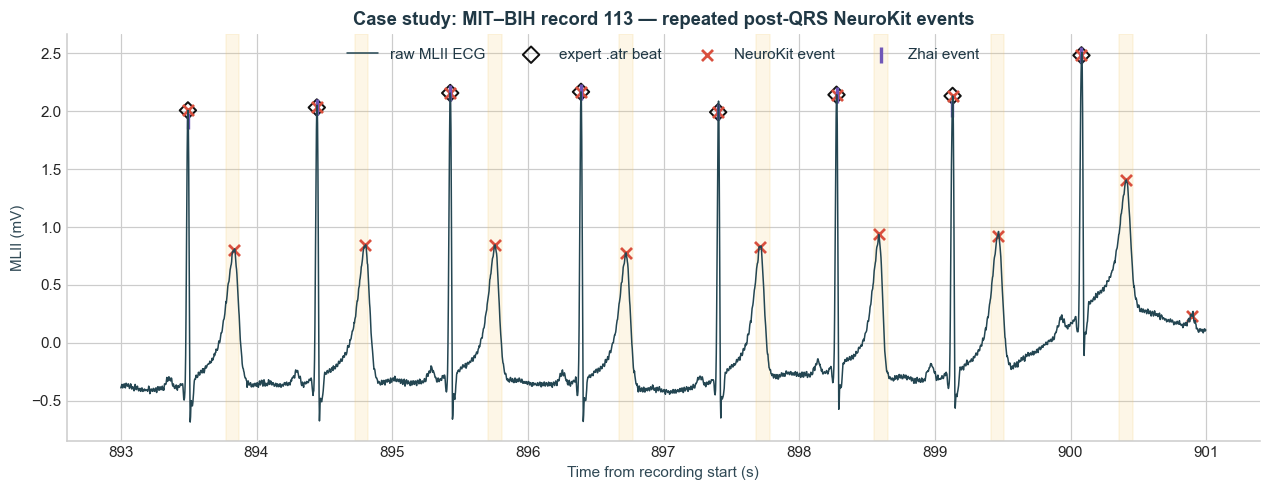

PASS — record 113 reproduces the audited extra-event pattern without calling it artifact.


In [9]:
from ecg_cascade.wfdb_io import load_wfdb_beat_annotations

CASE_RECORD = (
    ROOT / "Datasets" / "mit-bih-arrhythmia-database-1.0"
    / "mit-bih-arrhythmia-database-1.0.0" / "113"
)
case_segment = load_wfdb_segment(
    CASE_RECORD, channel="MLII", start_s=893.0, duration_s=8.0
)
case_cascade = run_neurokit_zhai_array(
    case_segment.samples,
    case_segment.sampling_rate_hz,
    segment_start_s=case_segment.start_s,
    config=config,
    source_metadata={"record": "113", "case": "post-QRS double detections"},
)

case_reference_samples, case_reference_symbols = load_wfdb_beat_annotations(CASE_RECORD)
case_reference_times_all = case_reference_samples / case_segment.sampling_rate_hz
case_reference_keep = (
    (case_reference_times_all >= case_segment.start_s)
    & (case_reference_times_all < case_segment.start_s + case_segment.duration_s)
)
case_reference_times = case_reference_times_all[case_reference_keep]
case_reference_symbols = np.asarray(case_reference_symbols)[case_reference_keep]

case_nk_times = (
    case_segment.start_s
    + case_cascade.selected.neurokit.detector.peak_samples / case_segment.sampling_rate_hz
)
case_zhai_times = (
    case_segment.start_s
    + case_cascade.selected.zhai.detector.peak_samples / case_segment.sampling_rate_hz
)
case_counts = pd.Series({
    "expert_atr_beats": case_reference_times.size,
    "NeuroKit_events": case_nk_times.size,
    "Zhai_events": case_zhai_times.size,
}, name="count")
display(case_counts.to_frame())

assert case_reference_times.size == 8
assert case_nk_times.size > 1.8 * case_reference_times.size
assert abs(case_zhai_times.size - case_reference_times.size) <= 1

case_time = case_segment.start_s + np.arange(case_segment.samples.size) / case_segment.sampling_rate_hz
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.plot(case_time, case_segment.samples, color="#244652", lw=1.0, label="raw MLII ECG")
for reference_time in case_reference_times:
    ax.axvspan(reference_time + 0.28, reference_time + 0.38, color="#f4c96b", alpha=.16)
ax.scatter(
    case_reference_times,
    np.interp(case_reference_times, case_time, case_segment.samples),
    marker="D", facecolors="none", edgecolors="#111111", s=58, linewidths=1.3,
    label="expert .atr beat",
)
ax.scatter(
    case_nk_times,
    np.interp(case_nk_times, case_time, case_segment.samples),
    marker="x", color="#d94f3d", s=52, linewidths=1.8,
    label="NeuroKit event",
)
ax.scatter(
    case_zhai_times,
    np.interp(case_zhai_times, case_time, case_segment.samples),
    marker="|", color="#7057b8", s=120, linewidths=2.2,
    label="Zhai event",
)
ax.set(
    title="Case study: MIT–BIH record 113 — repeated post-QRS NeuroKit events",
    xlabel="Time from recording start (s)", ylabel="MLII (mV)",
)
ax.legend(ncol=4, loc="upper center")
plt.show()
print("PASS — record 113 reproduces the audited extra-event pattern without calling it artifact.")

### How to read the successful-run screenshot

1. Hollow black diamonds are expert-annotated beats and should sit on the
   large QRS complexes.
2. Purple Zhai ticks should be close to those eight expert beats in this
   particular strip.
3. Red NeuroKit crosses should appear both on QRS complexes and on many
   broad post-QRS waves. The pale amber bands mark the report's measured
   280–380 ms post-QRS region as a visual guide, not a decision threshold.
4. The count table should show 8 expert beats, about 8 Zhai events, and
   about 17 NeuroKit events. That is a detector-specific case result—not
   a general ranking and not an artifact label.

## 7. Export auditable branch tables

#### Code walkthrough — export independent event, RR, and HRV tables

        **Why this cell exists.** A final matrix is not auditable unless the intermediate timestamp and interval ownership tables remain available.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Track loop | Visits NeuroKit and Zhai separately. | No output filename can hide which detector owns the timestamps. |
| 2 | Table map | Assigns distinct event, RR, and feature CSV files. | Reviewers can trace a feature row back to its endpoints. |
| 3 | CSV write | Writes each table without a synthetic index and records its shape. | Row/column counts provide a quick completeness check. |
| 4 | Configuration write | Saves the same parameter dictionary shown earlier. | Data and settings travel together. |

        **Evidence that the cell ran correctly**

        - Six CSV files plus `configuration.json` exist.
- The displayed shape table has nonzero rows and columns for both tracks.

        **If that evidence is absent, investigate**

        - An empty table caused by a detector or warm-up failure.
- Overwriting one track with the other's filename.
- A configuration file inconsistent with the printed settings.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [10]:
exported = {}
for name, track in tracks.items():
    stem = name.casefold()
    tables = {
        f"{stem}_events.csv": track.events,
        f"{stem}_rr_intervals.csv": track.rr_intervals,
        f"{stem}_rr_hrv_features.csv": track.features,
    }
    for filename, frame in tables.items():
        path = OUTPUT_DIR / filename
        frame.to_csv(path, index=False)
        exported[filename] = {"rows": len(frame), "columns": len(frame.columns)}
(OUTPUT_DIR / "configuration.json").write_text(json.dumps(config.to_dict(), indent=2), encoding="utf-8")
display(pd.DataFrame(exported).T)

,rows,columns
neurokit_events.csv,148,11
neurokit_rr_intervals.csv,147,14
neurokit_rr_hrv_features.csv,147,34
zhai_events.csv,148,12
zhai_rr_intervals.csv,147,14
zhai_rr_hrv_features.csv,147,34


## 8. Automated notebook-level acceptance checks

These assertions complement—not replace—the package test suite. They
verify this concrete run: finite input, increasing timestamps, positive
RR intervals, same-track ownership, defined 100-RR outputs, retained
reliability flags, and absence of classifier outputs.

#### Code walkthrough — enforce notebook-level RR/HRV invariants

        **Why this cell exists.** A figure can look plausible while timestamps are unordered, intervals are non-positive, or classifier outputs have leaked into preprocessing.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Ordering | Requires strictly increasing detector sample indices. | RR intervals need chronological events. |
| 2 | Physiology-independent arithmetic | Requires positive RR durations and at least one defined mature feature. | These are construction invariants, not clinical thresholds. |
| 3 | Context schema | Requires defined/reliable/coverage columns and unmoved detector timestamps. | Measurement and reliability stay separate. |
| 4 | Scope guard | Confirms seizure and artifact classifiers were not applied. | This notebook remains preprocessing-only. |

        **Evidence that the cell ran correctly**

        - The cell ends with the green-path sentence `PASS — RR/HRV notebook completed all acceptance checks.`

        **If that evidence is absent, investigate**

        - The first assertion named in the traceback; it identifies the violated invariant.
- A detector/configuration change before weakening any check.
- Any new probability or clinical-label column, which belongs in a separately validated model.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [11]:
for name, track in tracks.items():
    assert np.all(np.diff(track.detector.peak_samples) > 0), name
    assert (track.rr_intervals["rr_ms"] > 0).all(), name
    assert track.features["feature_defined"].any(), name
    assert {"feature_defined", "feature_reliable", "rr_reliability_coverage"}.issubset(track.features.columns)
    assert not track.events["timestamp_moved_after_detection"].any(), name
assert cascade.metadata["seizure_classifier_applied"] is False
assert cascade.metadata["artifact_classifier_applied"] is False
print("PASS — RR/HRV notebook completed all acceptance checks.")

PASS — RR/HRV notebook completed all acceptance checks.


## Interpretation limits

- Detector agreement is not expert truth and not signal quality.
- The 100-RR features are mathematically defined only after 100 intervals.
- Reliability means the configured detector-support condition passed; it
  is not clinical validity.
- No target-seizure discrimination, threshold calibration, artifact
  classification, or patient-level validation occurs here.
- NeuroKit and Zhai remain parallel candidates until expert-annotation
  evidence selects an owner for the intended population and device.

## Exact implementation appendix

To make the executed notebook a durable audit artifact, this section
embeds the **complete source text** of the modules used above and records
a SHA-256 digest for each file. The algorithms are imported from these
tested modules; they are not rewritten in a second, drifting notebook copy.

#### Code walkthrough — embed exact implementation source and cryptographic hashes

        **Why this cell exists.** A notebook can otherwise become an attractive but stale copy of production code; this cell records precisely what implementation was executed.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Source list | Freezes the branch modules and scripts included in the appendix. | The reader can audit the implementation boundary. |
| 2 | File loop | Reads every file as UTF-8, counts lines, and calculates SHA-256. | A one-character source change produces a different digest. |
| 3 | Rendered source | Displays the complete Python text in the executed notebook. | Every internal line remains reviewable without opening a second application. |
| 4 | Manifest export | Writes `source_manifest.json` and displays its table. | Automated checks can compare filenames, line counts, and hashes later. |

        **Evidence that the cell ran correctly**

        - Each expected module appears as a rendered code block with a 64-character SHA-256 digest.
- The final table contains one row per requested source file and positive line counts.
- `source_manifest.json` is saved in the branch output directory.

        **If that evidence is absent, investigate**

        - A source module that moved or is missing.
- An unexpected project root, which would hash the wrong files.
- Notebook size limits if a front end refuses to render the complete appendix.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [12]:
SOURCE_FILES = ['src/ecg_cascade/config.py', 'src/ecg_cascade/wfdb_io.py', 'src/ecg_cascade/peaks.py', 'src/ecg_cascade/zhai.py', 'src/ecg_cascade/rr_hrv.py', 'src/ecg_cascade/neurokit_zhai.py']
source_manifest = []
for relative in SOURCE_FILES:
    path = PROJECT / relative
    text = path.read_text(encoding="utf-8")
    digest = hashlib.sha256(text.encode("utf-8")).hexdigest()
    source_manifest.append({"file": relative, "sha256": digest, "lines": len(text.splitlines())})
    display(Markdown(f"### `{relative}`  \nSHA-256: `{digest}` · {len(text.splitlines())} lines"))
    display(Code(text, language="python"))

source_manifest_path = OUTPUT_DIR / "source_manifest.json"
source_manifest_path.write_text(json.dumps(source_manifest, indent=2), encoding="utf-8")
display(pd.DataFrame(source_manifest))
print("Saved:", source_manifest_path)

### `src/ecg_cascade/config.py`  
SHA-256: `fedb79ad48b89f8a089b03ae32e28f93ad453105df715ef2f4c17a4da6728906` · 159 lines

"""Configuration for the evidence-traceable RR--HRV branch."""

from __future__ import annotations

from dataclasses import asdict, dataclass


@dataclass(frozen=True)
class NeuroKitZhaiConfig:
    """Configuration for the independent NeuroKit-versus-Zhai architecture.

    Neither track is declared the RR owner.  The architecture calculates both
    RR/HRV series and leaves ownership to annotation-based validation.
    """

    processing_orientation: str = "original"
    compute_inverted_context: bool = False
    neurokit_minimum_delay_ms: float = 300.0
    neurokit_minimum_delay_inclusive: bool = False
    support_tolerance_ms: float = 50.0
    audit_match_tolerance_ms: float = 75.0
    hrv_window_rr_intervals: int = 100
    causal_rr_median_width: int = 7
    reliable_hrv_coverage: float = 1.0
    # The primary implementation follows the later peer-reviewed Varon 2015
    # study: a symmetric 120-ms capture.  The 2013 80-ms version remains an
    # explicit ablation by passing 40 ms on each side.
    varon_pre_r_ms: float = 60.0
    varon_post_r_ms: float = 60.0
    varon_stack_beats: int = 5
    reliable_morphology_support_coverage: float = 1.0

    def __post_init__(self) -> None:
        if self.processing_orientation not in {"original", "inverted"}:
            raise ValueError("processing_orientation must be 'original' or 'inverted'")
        for name in [
            "neurokit_minimum_delay_ms",
            "support_tolerance_ms",
            "audit_match_tolerance_ms",
        ]:
            if getattr(self, name) <= 0:
                raise ValueError(f"{name} must be positive")
        if self.hrv_window_rr_intervals < 3:
            raise ValueError("hrv_window_rr_intervals must be at least 3")
        if self.causal_rr_median_width <= 0:
            raise ValueError("causal_rr_median_width must be positive")
        if not 0 <= self.reliable_hrv_coverage <= 1:
            raise ValueError("reliable_hrv_coverage must be between 0 and 1")
        if self.varon_pre_r_ms <= 0 or self.varon_post_r_ms <= 0:
            raise ValueError("Varon QRS capture durations must be positive")
        if self.varon_stack_beats != 5:
            raise ValueError(
                "The paper-traceable Varon core requires varon_stack_beats=5"
            )
        if not 0 <= self.reliable_morphology_support_coverage <= 1:
            raise ValueError(
                "reliable_morphology_support_coverage must be between 0 and 1"
            )

    def to_dict(self) -> dict[str, object]:
        payload = asdict(self)
        payload.update(
            {
                "timestamp_owner": "unselected_pending_annotation_validation",
                "raw_amplitude_argmax_refinement": False,
                "automatic_detector_fusion": False,
                "automatic_polarity_routing": False,
                "morphology_core": (
                    "Varon_2015_five_QRS_symmetric_120ms_Gram_eigenvalues"
                ),
                "delineation_lane": "not_run_separate_future_integration",
                "fusion_status": "measurements_joined_no_classifier",
                "zhai_status": (
                    "independent_paper_reimplementation; no official author "
                    "code located"
                ),
            }
        )
        return payload


@dataclass(frozen=True)
class RRHRVConfig:
    """Parameters which materially change RR/HRV extraction.

    The defaults implement the current architecture, while keeping every
    experimental choice visible in metadata.  In particular, 250 ms is the
    requested experimental NeuroKit delay; the unmodified 300-ms result is
    always computed as a baseline.
    """

    primary_detector: str = "unsw"
    secondary_detector: str = "neurokit"
    processing_orientation: str = "original"
    compute_inverted_context: bool = True
    neurokit_experimental_min_delay_ms: float = 250.0
    neurokit_baseline_min_delay_ms: float = 300.0
    min_delay_inclusive: bool = T

### `src/ecg_cascade/wfdb_io.py`  
SHA-256: `ce22583ed274a23a180aa66e21aca26588087ec7fb5c4b5d4b9098b3a0e2b545` · 122 lines

"""Explicit WFDB loading for annotated MIT--BIH validation records."""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import wfdb


@dataclass(frozen=True)
class WFDBSegment:
    record_path: str
    channel_index: int
    channel_name: str
    sampling_rate_hz: float
    start_sample: int
    samples: np.ndarray

    @property
    def start_s(self) -> float:
        return self.start_sample / self.sampling_rate_hz

    @property
    def duration_s(self) -> float:
        return self.samples.size / self.sampling_rate_hz


def load_wfdb_segment(
    record_path: str | Path,
    *,
    channel: int | str = 0,
    start_s: float = 0.0,
    duration_s: float | None = None,
) -> WFDBSegment:
    """Load one verified WFDB channel; ``record_path`` omits the extension."""

    record_path = Path(record_path).expanduser().resolve()
    header_path = record_path.with_suffix(".hea")
    if not header_path.is_file():
        raise FileNotFoundError(header_path)
    header = wfdb.rdheader(str(record_path))
    fs = float(header.fs)
    if start_s < 0:
        raise ValueError("start_s must be non-negative")
    if duration_s is not None and duration_s <= 0:
        raise ValueError("duration_s must be positive")
    if isinstance(channel, str):
        matches = [
            index
            for index, name in enumerate(header.sig_name)
            if name.casefold() == channel.casefold()
        ]
        if len(matches) != 1:
            raise ValueError(
                f"Channel {channel!r} matched {len(matches)} channels; "
                f"available={header.sig_name}"
            )
        channel_index = matches[0]
    else:
        channel_index = int(channel)
        if not 0 <= channel_index < int(header.n_sig):
            raise ValueError(
                f"channel index {channel_index} outside 0..{int(header.n_sig)-1}"
            )
    start_sample = int(np.rint(start_s * fs))
    if start_sample >= int(header.sig_len):
        raise ValueError("start_s lies beyond the WFDB record")
    if duration_s is None:
        end_sample = int(header.sig_len)
    else:
        end_sample = min(
            int(header.sig_len), start_sample + int(np.rint(duration_s * fs))
        )
    record = wfdb.rdrecord(
        str(record_path),
        sampfrom=start_sample,
        sampto=end_sample,
        channels=[channel_index],
        physical=True,
    )
    samples = np.asarray(record.p_signal[:, 0], dtype=np.float64)
    if not np.all(np.isfinite(samples)):
        raise ValueError("WFDB segment contains non-finite ECG samples")
    return WFDBSegment(
        record_path=str(record_path),
        channel_index=channel_index,
        channel_name=str(header.sig_name[channel_index]),
        sampling_rate_hz=fs,
        start_sample=start_sample,
        samples=samples,
    )


def load_wfdb_beat_annotations(
    record_path: str | Path,
    *,
    extension: str = "atr",
    start_sample: int = 0,
    end_sample: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Load reference beat samples and symbols, excluding non-beat markers."""

    record_path = Path(record_path).expanduser().resolve()
    annotation = wfdb.rdann(str(record_path), extension)
    samples = np.asarray(annotation.sample, dtype=np.int64)
    symbols = np.asarray(annotation.symbol, dtype=object)
    # WFDB beat labels documented for the MIT--BIH annotations.  Rhythm,
    # waveform, comment, and signal-quality markers are intentionally absent.
    beat_symbols = {
        "N", "L", "R", "B", "A", "a", "J", "S", "V", "r", "F",
        "e", "j", "n", "E", "/", "f", "Q", "?",
    }
    keep = np.array(
        [symbol in beat_symbols for symbol in symbols],
        dtype=bool,
    )
    keep &= samples >= start_sample
    if end_sample is not None:
        keep &= samples < end_sample
    return samples[keep] - start_sample, symbols[keep]

### `src/ecg_cascade/peaks.py`  
SHA-256: `5105c5d19bf5c421d5c068312f243dc02dc91ea9cdc4e8d2e0a6cd96aed26207` · 446 lines

...

"""Continuous RR/HRV measurements from the Jeppesen phase-3 method."""

from __future__ import annotations

import numpy as np
import pandas as pd

from .peaks import PeakAgreement


def causal_median_filter(values: np.ndarray, width: int = 7) -> np.ndarray:
    values = np.asarray(values, dtype=np.float64)
    if width <= 0:
        raise ValueError("Median-filter width must be positive")
    result = np.empty_like(values)
    for index in range(values.size):
        first = max(0, index - width + 1)
        result[index] = np.median(values[first : index + 1])
    return result


def poincare_axes(rr_ms: np.ndarray) -> tuple[float, float]:
    """Return standard Poincare SD1 and SD2 from successive RR pairs."""

    rr = np.asarray(rr_ms, dtype=np.float64)
    if rr.size < 3 or not np.all(np.isfinite(rr)):
        return np.nan, np.nan
    x1 = rr[:-1]
    x2 = rr[1:]
    sd1 = np.std((x2 - x1) / np.sqrt(2.0), ddof=1)
    sd2 = np.std((x2 + x1) / np.sqrt(2.0), ddof=1)
    return float(sd1), float(sd2)


def absolute_least_squares_slope(
    time_s: np.ndarray, heart_rate_bpm: np.ndarray
) -> float:
    time_s = np.asarray(time_s, dtype=np.float64)
    heart_rate_bpm = np.asarray(heart_rate_bpm, dtype=np.float64)
    if time_s.size < 2 or not np.all(np.isfinite(time_s + heart_rate_bpm)):
        return np.nan
    centered_time = time_s - np.mean(time_s)
    denominator = np.sum(centered_time**2)
    if denominator <= 0:
        return np.nan
    slope = np.sum(centered_time * (heart_rate_bpm - np.mean(heart_rate_bpm)))
    return float(abs(slope / denominator))


def calculate_jeppesen_feature_arrays(
    rr_ms: np.ndarray,
    *,
    end_time_s: np.ndarray | None = None,
    window_size: int = 100,
    median_width: int = 7,
) -> pd.DataFrame:
    """Vectorized form of the implemented Jeppesen 100-RR equations.

    This function is intended for multi-track validation.  It calculates the
    same continuous values as :func:`extract_rr_hrv_features` from an already
    constructed RR series.  If no coherent event-timestamp axis exists,
    ``end_time_s=None`` uses the cumulative RR tachogram as the time axis and
    exposes that choice to the caller.
    """

    rr = np.asarray(rr_ms, dtype=np.float64)
    if rr.ndim != 1:
        raise ValueError("rr_ms must be one-dimensional")
    if not np.all(np.isfinite(rr)) or np.any(rr <= 0):
        raise ValueError("RR intervals must be finite and strictly positive")
    if window_size < 3:
        raise ValueError("window_size must be at least three")
    if median_width <= 0:
        raise ValueError("median_width must be positive")
    if end_time_s is None:
        times = np.cumsum(rr) / 1000.0
    else:
        times = np.asarray(end_time_s, dtype=np.float64)
        if times.shape != rr.shape:
            raise ValueError("end_time_s must have one value per RR interval")
        if not np.all(np.isfinite(times)) or (
            times.size > 1 and np.any(np.diff(times) <= 0)
        ):
            raise ValueError("end_time_s must be finite and strictly increasing")

    filtered = causal_median_filter(rr, median_width)
    count = rr.size
    result = pd.DataFrame(
        {
            "rr_ms": rr,
            f"rr_median{median_width}_ms": filtered,
            "end_time_s": times,
            "sd1_raw_ms": np.full(count, np.nan),
            "sd2_raw_ms": np.full(count, np.nan),
            "csi100": np.full(count, np.nan),
            "sd1_filtered_ms": np.full(count, np.nan),
            "sd2_filtered_ms": np.full(count, np.nan),
            "modcsi100_filtered_ms": np.full(count, np.nan),
            "slope100_bpm_per_s": np.full(count, np.nan),
            "j1_csi_x_slope": np.full(count, np.nan),
            "j2_modcsi_filtered_x_slope": np.full(count, np.nan),
            "feature_defined": np.zeros(count, dtype=bool),
        }
    )
    if count < window_size:
        return result

    pair_width = window_size - 1
    root_two = np.sqrt(2.0)
    raw_minor = np.di

### `src/ecg_cascade/neurokit_zhai.py`  
SHA-256: `e1e257a757ee26b96a4e5acebd2d335a6390b8f391a70985a452baaadb5f7db9` · 675 lines

"""Independent NeuroKit and Zhai RR--HRV tracks.

This module implements the architecture selected for the next audit:

raw ECG -> NeuroKit detector -> NeuroKit RR/HRV
        +-> Zhai detector     -> Zhai RR/HRV

The detector outputs are compared but never averaged, majority-voted, or
spliced beat by beat.  The code also deliberately avoids the previous local
positive-amplitude R-fiducial refinement.
"""

from __future__ import annotations

from dataclasses import asdict, dataclass
from importlib.metadata import version
import json
from pathlib import Path

import numpy as np
import pandas as pd

from .config import NeuroKitZhaiConfig
from .edf import SignalSegment, load_ecg_segment
from .fusion import build_detector_association_table, build_fusion_ready_table
from .morphology import VaronMorphologyResult, extract_varon_morphology
from .peaks import DetectorRun, PeakAgreement, compare_peak_sequences, detect_neurokit_gradient
from .prsa_bprsa import PRSABPRSAResult, extract_prsa_bprsa_features
from .rr_hrv import extract_rr_hrv_windows
from .wfdb_io import WFDBSegment, load_wfdb_segment
from .zhai import ZhaiDetection, detect_zhai_template


@dataclass(frozen=True)
class TimestampTrackResult:
    """One detector's unmodified timestamps and downstream RR/HRV output."""

    name: str
    detector: DetectorRun
    events: pd.DataFrame
    rr_intervals: pd.DataFrame
    features: pd.DataFrame
    morphology: VaronMorphologyResult
    prsa_bprsa_context: PRSABPRSAResult
    fusion_ready: pd.DataFrame

    def summary(self) -> dict[str, object]:
        return {
            "name": self.name,
            "detector": self.detector.summary(),
            "event_count": int(self.events.shape[0]),
            "supported_event_count": int(self.events["qrs_supported"].sum()),
            "event_support_fraction": _finite_or_none(
                float(self.events["qrs_supported"].mean())
                if not self.events.empty
                else np.nan
            ),
            "rr_interval_count": int(self.rr_intervals.shape[0]),
            "supported_rr_count": int(self.rr_intervals["rr_supported"].sum()),
            "rr_support_fraction": _finite_or_none(
                float(self.rr_intervals["rr_supported"].mean())
                if not self.rr_intervals.empty
                else np.nan
            ),
            "defined_hrv_rows": int(self.features["feature_defined"].sum()),
            "reliable_hrv_rows": int(self.features["feature_reliable"].sum()),
            "morphology": self.morphology.summary(),
            "prsa_bprsa_context": self.prsa_bprsa_context.summary(),
            "fusion_ready_row_count": int(self.fusion_ready.shape[0]),
            "fusion_defined_row_count": int(
                self.fusion_ready["fusion_measurements_defined"].sum()
            ),
            "timestamp_adjustment": "none_detector_output_used_directly",
        }


@dataclass(frozen=True)
class NeuroKitZhaiOrientationResult:
    orientation: str
    neurokit: TimestampTrackResult
    zhai: TimestampTrackResult
    zhai_detection: ZhaiDetection
    support_agreement: PeakAgreement
    audit_agreement: PeakAgreement
    detector_associations: pd.DataFrame

    def summary(self) -> dict[str, object]:
        return {
            "orientation": self.orientation,
            "neurokit": self.neurokit.summary(),
            "zhai": self.zhai.summary(),
            "zhai_intermediates": self.zhai_detection.summary(),
            "support_tolerance_agreement": self.support_agreement.to_dict(),
            "audit_tolerance_agreement": self.audit_agreement.to_dict(),
            "detector_association_rows": int(self.detector_associations.shape[0]),
            "timestamp_owner": "unselected_pending_annotation_validation",
        }


@dataclass(frozen=True)
class NeuroKitZhaiResult:
    selected_orientation: str
    selected: NeuroKitZhaiOrientationResult
    orientations: dict[str, NeuroKitZhaiOrientationResult]
    config: NeuroKitZhaiConfi

,file,sha256,lines
0,src/ecg_cascade/config.py,fedb79ad48b89f8a089b03ae32e28f93ad453105df715e...,159
1,src/ecg_cascade/wfdb_io.py,ce22583ed274a23a180aa66e21aca26588087ec7fb5c4b...,122
2,src/ecg_cascade/peaks.py,5105c5d19bf5c421d5c068312f243dc02dc91ea9cdc4e8...,446
3,src/ecg_cascade/zhai.py,1287f982727df2ee101ea6e35dc9f008a98bc73821372e...,444
4,src/ecg_cascade/rr_hrv.py,b54777cd36723c0e5028c282ea43f19b292b45bdc787a4...,468
5,src/ecg_cascade/neurokit_zhai.py,e1e257a757ee26b96a4e5acebd2d335a6390b8f391a709...,675


Saved: C:\Users\Salam\Documents\ECGdetector\feature_extraction\outputs\standalone_notebooks\rr_hrv\source_manifest.json
